In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

In [2]:
#import data
df_ori = pd.read_excel('/Users/surajbhula/Desktop/Capstone Project/PCA Attempts/Final PCA/DB_ESCA(Master).xlsx')

#set index
df_ori = df_ori.set_index(['site_code','sample_date'])
df_ori.head(5)


latitude   longitude  elevation broad_classes  \
site_code sample_date                                                   
AA09      2000-05-04   33.724639 -111.830603        838        Desert   
          2005-03-04   33.724639 -111.830603        838        Desert   
          2010-03-29   33.724639 -111.830603        838        Desert   
          2015-06-01   33.724639 -111.830603        838        Desert   
AA11      2000-05-01   33.643044 -111.819336        909        Desert   

                      detailed_classes specific_classes  urban       clay  \
site_code sample_date                                                       
AA09      2000-05-04            Desert           Desert    0.0   7.620870   
          2005-03-04            Desert           Desert    0.0  15.714548   
          2010-03-29            Desert           Desert    0.0  15.621983   
          2015-06-01            Desert           Desert    0.0  11.969473   
AA11      2000-05-01            Desert           Desert    0.0  16.780106   

                            sand       silt  ...  WASFRO  WASHIN  WISSIN  \
site_code sample_date                        ...                           
AA09      2000-05-04   79.431386  12.947744  ...   False   False   False   
          2005-03-04   71.913355  12.372097  ...   False   False   False   
          2010-03-29   70.042447  14.335570  ...   False   False   False   
          2015-06-01   73.427124  14.603403  ...   False   False   False   
AA11      2000-05-01   44.920518  38.299376  ...   False   False   False   

                       XANSPI  YUCGTR  ZEAMAY  ZIZIPH  ZOYJAP  \
site_code sample_date                                           
AA09      2000-05-04    False   False   False   False   False   
          2005-03-04    False   False   False   False   False   
          2010-03-29    False   False   False   False   False   
          2015-06-01    False   False   False   False   False   
AA11      2000-05-01    False   False   False   False   False   

                       species_richness  rope_length_annual_cover  
site_code sample_date                                              
AA09      2000-05-04                  6                       NaN  
          2005-03-04                 17                       NaN  
          2010-03-29                 29                       0.5  
          2015-06-01                  8                       NaN  
AA11      2000-05-01                  1                       NaN  

[5 rows x 708 columns]

In [3]:
#drop na values
df = df_ori.dropna (subset=['clay','sand','ammonT','nitrT','phosT','icarbT','ocarbT','pH','conduct','swcT','bulkdens','ONCPIL', 'broad_classes'])

In [4]:
#slice numerical columns
#included in this PCA: clay, sand, ammonT, nitrT, phosT, icarbT, ocarbT, pH, conduct, swcT, bulkdens (This will remove 2023 sample data) 

x=df.iloc[:, np.r_[7,8,10,12,14,18,20,24,25,26,30]]
x.head(5)

clay       sand    ammonT     nitrT      phosT  \
site_code sample_date                                                        
AA09      2005-03-04   15.714548  71.913355  4.439779  1.021854  17.246859   
          2010-03-29   15.621983  70.042447  0.703434  5.547698  55.582188   
          2015-06-01   11.969473  73.427124  2.617424  4.801891  13.318114   
AA11      2000-05-01   16.780106  44.920518  4.697252  6.490025  60.789557   
          2010-04-16   11.594915  55.722520  1.736679  0.741629  50.179813   

                       icarbT  ocarbT    pH  conduct      swcT  bulkdens  
site_code sample_date                                                     
AA09      2005-03-04    0.069   0.559  7.85   0.2160  6.902087  1.302980  
          2010-03-29    0.025   0.537  7.05   0.1580  3.888889  1.753085  
          2015-06-01    0.026   0.282  7.84   0.2660  2.698413  1.637128  
AA11      2000-05-01    0.062   1.725  7.94   0.4105  0.807230  1.483217  
          2010-04-16    0.140   1.512  8.11   0.2830  1.308411  1.470481

In [5]:
#data transformation (yeo-johnson)
x_scaled = sklearn.preprocessing.power_transform(x, method='yeo-johnson')
x_scaled = pd.DataFrame(x_scaled, columns = x.columns, index=x.index)
x_scaled.head(5)

clay      sand    ammonT     nitrT     phosT  \
site_code sample_date                                                     
AA09      2005-03-04   0.370795  0.601511  0.717216 -1.181588  0.275699   
          2010-03-29   0.358081  0.463910 -0.948547 -0.158243  1.502919   
          2015-06-01  -0.185158  0.713891  0.209899 -0.250795 -0.006065   
AA11      2000-05-01   0.513982 -1.232540  0.770128 -0.058426  1.592614   
          2010-04-16  -0.246219 -0.539437 -0.182885 -1.333290  1.399702   

                         icarbT    ocarbT        pH   conduct      swcT  \
site_code sample_date                                                     
AA09      2005-03-04  -1.063477  0.054417 -0.550522 -0.631089  0.461634   
          2010-03-29  -1.320733  0.001388 -1.736805 -1.013492 -0.215669   
          2015-06-01  -1.314565 -0.765660 -0.568998 -0.350796 -0.627190   
AA11      2000-05-01  -1.102545  1.538439 -0.379490  0.269357 -1.746948   
          2010-04-16  -0.702188  1.381329 -0.032174 -0.264376 -1.353593   

                       bulkdens  
site_code sample_date            
AA09      2005-03-04  -0.554518  
          2010-03-29   1.544316  
          2015-06-01   0.984883  
AA11      2000-05-01   0.262190  
          2010-04-16   0.203421

In [6]:
from sklearn.decomposition import PCA

#create pca model
pca = PCA(n_components=3, svd_solver='full')

#fit data to model
x_pca = pca.fit_transform(x_scaled)
x_pca = pd.DataFrame(x_pca, columns = ['PC1','PC2', 'PC3'], index=x.index)

print(x_pca)

#variance explained by each component
variance = pca.explained_variance_ratio_
print()
print("Variance for PC1, PC2, and PC3")
print(variance)

#weight of each variable
loadings = pca.components_
print(loadings)



                            PC1       PC2       PC3
site_code sample_date                              
AA09      2005-03-04  -0.441182 -0.557605 -1.302537
          2010-03-29  -0.851795 -1.405061 -1.713900
          2015-06-01  -1.476768 -1.039031 -0.431792
AA11      2000-05-01   0.942585 -2.003212 -0.987862
          2010-04-16  -0.301252 -0.974944 -1.272459
...                         ...       ...       ...
Z21       2000-03-23   3.720701  0.173189  0.096359
          2005-02-28   2.609366  1.325657 -1.522546
          2010-02-24   4.096209  1.566987 -1.571880
          2015-06-05   2.695805 -0.701160  0.254091
Z23       2005-04-15   0.465355  0.709860  0.495301

[543 rows x 3 columns]

Variance for PC1, PC2, and PC3
[0.30664798 0.15193827 0.1299922 ]
[[ 0.39883797 -0.40221615  0.13336767  0.32303746  0.23361023  0.19878882
   0.3336424  -0.08180716  0.41846729  0.33775005 -0.23605072]
 [ 0.19559218 -0.19701406 -0.45129059 -0.22085999 -0.19610724  0.35626274
  -0.31367144  0.52352

Axes(0.125,0.11;0.775x0.77)


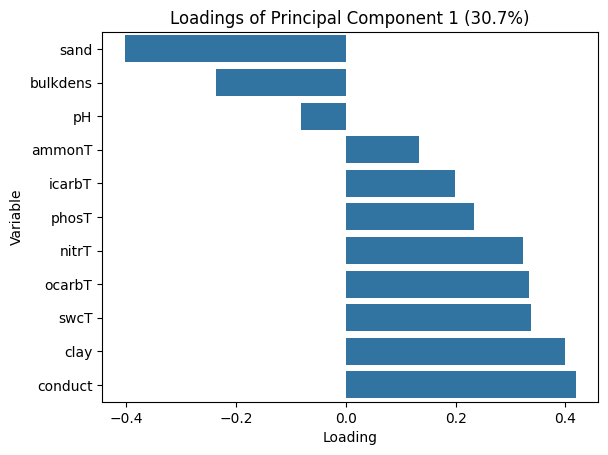

In [7]:
#PC1 bar chart for loadings
loadings_df1 = pd.DataFrame ({
    'Variable' : x.columns,
    'Loading' : loadings[0]})

loadings_df1 = loadings_df1.sort_values(by='Loading')

graph = sns.barplot(data=loadings_df1, x = 'Loading' , y = 'Variable', orient = "y")
graph.set_title("Loadings of Principal Component 1 (30.7%)")
print(graph)

Axes(0.125,0.11;0.775x0.77)


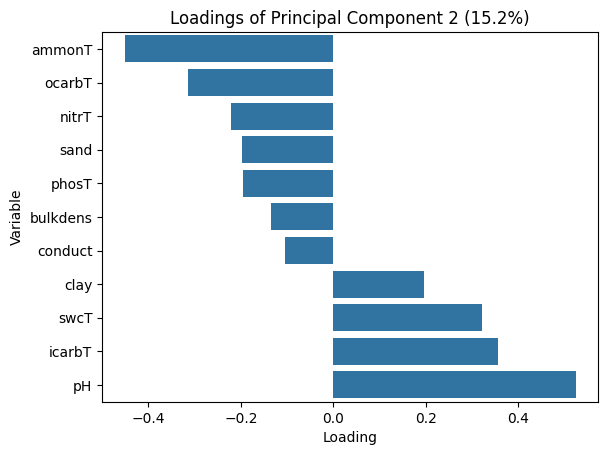

In [8]:
#PC2 bar chart for loadings

loadings_df2 = pd.DataFrame ({
    'Variable' : x.columns,
    'Loading' : loadings[1]})

loadings_df2 = loadings_df2.sort_values(by='Loading')

graph = sns.barplot(data=loadings_df2, x = 'Loading' , y = 'Variable', orient = "y")
graph.set_title("Loadings of Principal Component 2 (15.2%)")
print(graph)

Axes(0.125,0.11;0.775x0.77)


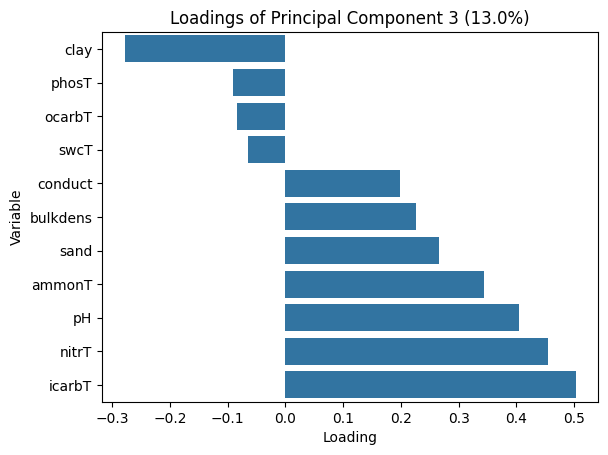

In [9]:
#PC3 bar chart for loadings

loadings_df3 = pd.DataFrame ({
    'Variable' : x.columns,
    'Loading' : loadings[2]})

loadings_df3 = loadings_df3.sort_values(by='Loading')

graph = sns.barplot(data=loadings_df3, x = 'Loading' , y = 'Variable', orient = "y")
graph.set_title("Loadings of Principal Component 3 (13.0%)")
print(graph)

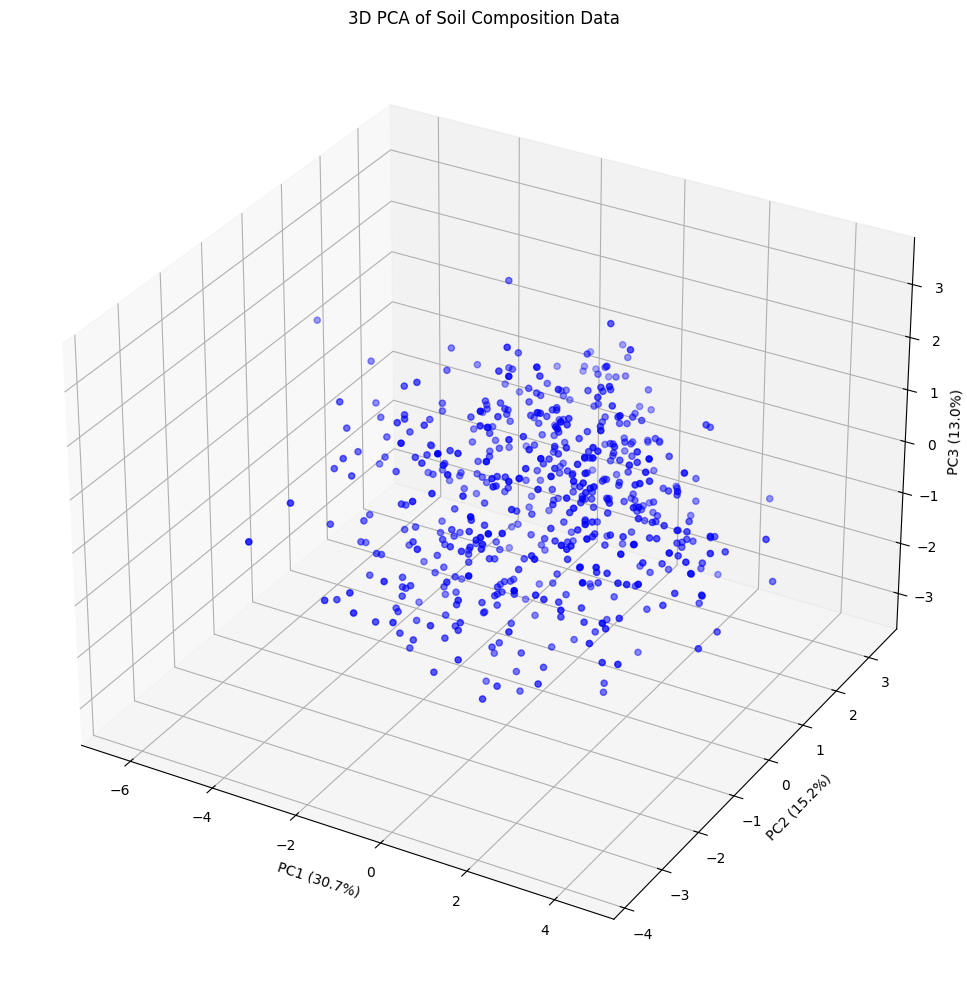

In [10]:
import matplotlib.pyplot as plt

#plot pca results
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot (1,1,1, projection ='3d')

ax.scatter(x_pca['PC1'],
             x_pca['PC2'],
             x_pca['PC3'],
             c='blue'
             )

ax.set_title ('3D PCA of Soil Composition Data')
ax.set_xlabel('PC1 (30.7%)')
ax.set_ylabel('PC2 (15.2%)')
ax.set_zlabel('PC3 (13.0%)',labelpad=1)
fig.tight_layout()

plt.show()

                            PC1       PC2       PC3  Present?    Land_Type
site_code sample_date                                                     
AA09      2005-03-04  -0.441182 -0.557605 -1.302537     False       Desert
          2010-03-29  -0.851795 -1.405061 -1.713900      True       Desert
          2015-06-01  -1.476768 -1.039031 -0.431792     False       Desert
AA11      2000-05-01   0.942585 -2.003212 -0.987862     False       Desert
          2010-04-16  -0.301252 -0.974944 -1.272459     False       Desert
...                         ...       ...       ...       ...          ...
Z21       2000-03-23   3.720701  0.173189  0.096359     False  Residential
          2005-02-28   2.609366  1.325657 -1.522546     False  Residential
          2010-02-24   4.096209  1.566987 -1.571880     False  Residential
          2015-06-05   2.695805 -0.701160  0.254091     False  Residential
Z23       2005-04-15   0.465355  0.709860  0.495301     False        Urban

[543 rows x 5 columns]


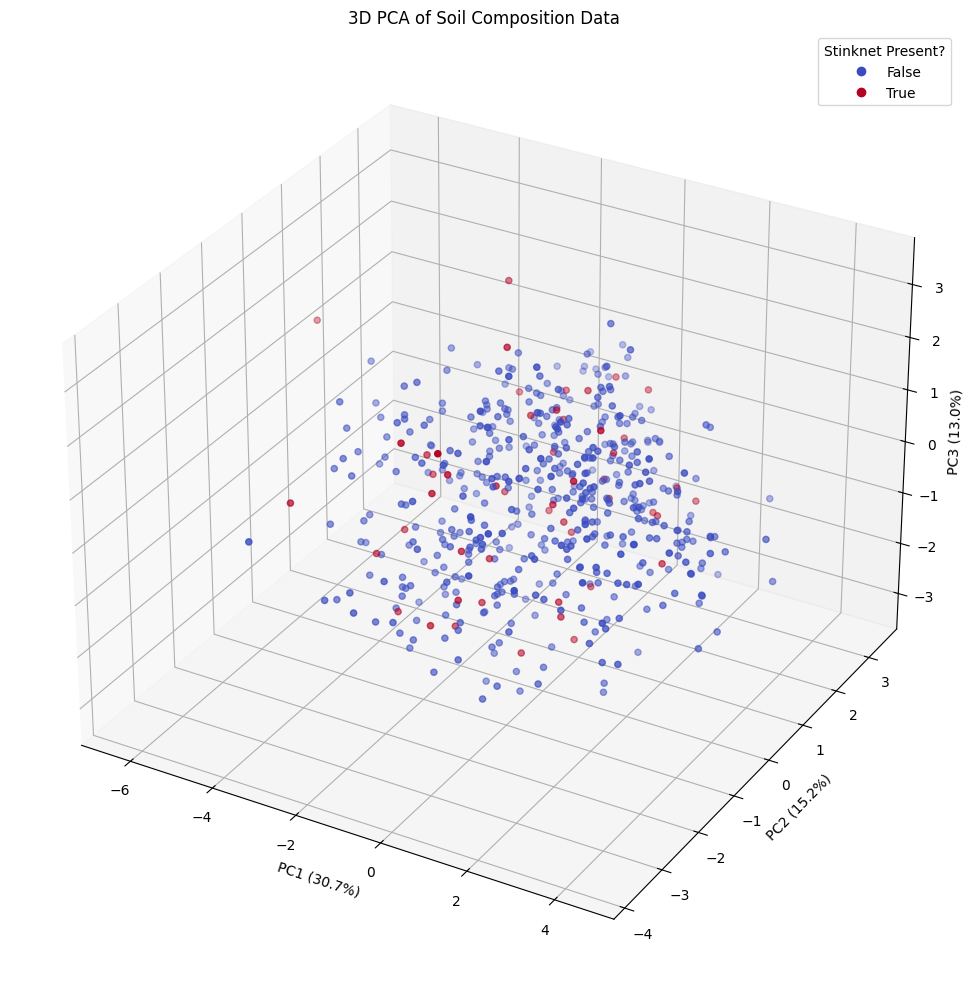

In [11]:
#add ONCPIL + broad_classes column to PCA dataframe
x_pca['Present?'] = df['ONCPIL']
x_pca['Land_Type'] = df['broad_classes']
print(x_pca)

fig1 = plt.figure(figsize=(10,10))


ax1 = fig1.add_subplot (1,1,1, projection ='3d')

ax2 = ax1.scatter(x_pca['PC1'],
             x_pca['PC2'],
             x_pca['PC3'],
             c=x_pca['Present?'],
             cmap='coolwarm'
             )

ax1.legend(handles=ax2.legend_elements()[0],
           labels = ['False','True'],
           title = 'Stinknet Present?')

ax1.set_title ('3D PCA of Soil Composition Data')
ax1.set_xlabel('PC1 (30.7%)')
ax1.set_ylabel('PC2 (15.2%)')
ax1.set_zlabel('PC3 (13.0%)', labelpad=1)
ax.dist = 10
fig1.tight_layout()

plt.show()



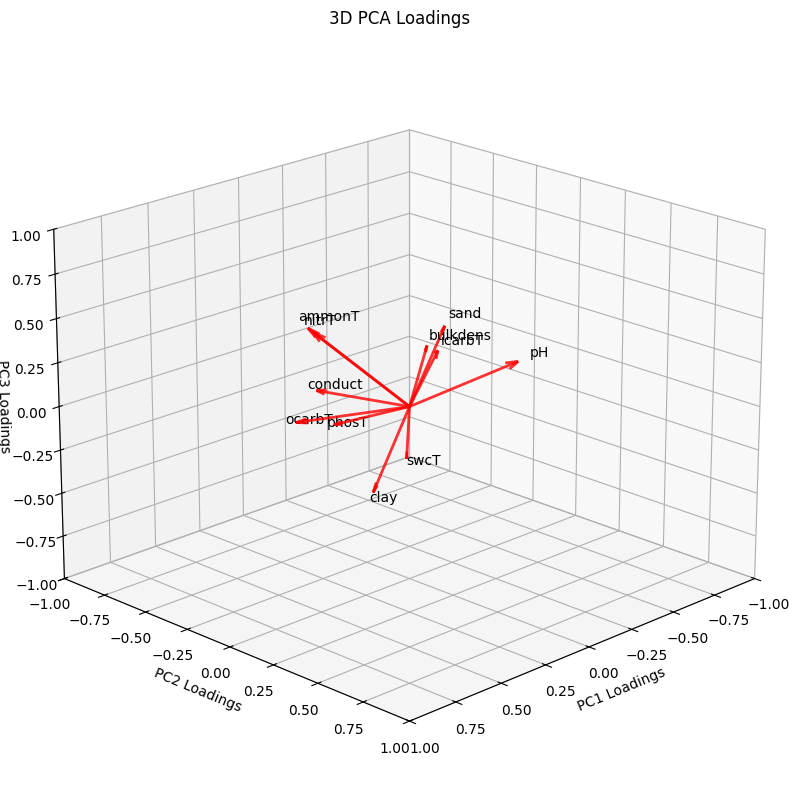

In [12]:
#PCA vector extraction
loadingsPC1 = loadings[0]
loadingsPC2 = loadings[1]
loadingsPC3 = loadings[2]

column_names = ['clay', 'sand', 'ammonT', 'nitrT', 'phosT', 'icarbT', 'ocarbT', 'pH', 'conduct', 'swcT', 'bulkdens']


#plot vectors
fig3 = plt.figure(figsize = (10,10))
ax3 = fig3.add_subplot(1,1,1, projection = '3d')

for i in range(len(column_names)):
    ax3.quiver(0,0,0,
              loadingsPC1[i],
              loadingsPC2[i],
              loadingsPC3[i],
              color='red', alpha=.8, lw=2, arrow_length_ratio=0.1)
    
    ax3.text(loadingsPC1[i] * 1.1,
            loadingsPC2[i] * 1.1,
            loadingsPC3[i] * 1.1,
            column_names[i],
            color='black')
    
ax3.set_xlim([-1,1])
ax3.set_ylim([-1,1])
ax3.set_zlim([-1,1])

ax3.set_xlabel('PC1 Loadings')
ax3.set_ylabel('PC2 Loadings')
ax3.set_zlabel('PC3 Loadings',labelpad=2)
ax3.set_title('3D PCA Loadings')
ax3.view_init(elev=20, azim=45)
ax3.grid(True)

plt.show()




In [13]:
#land type values
print(x_pca['Land_Type'].unique())

['Desert' 'Urban' 'Residential' 'AgriculturalLand' 'Vacant'
 'Transportation' 'GolfCourse/park']


In [14]:
#subset data to Urban Desert Residential land
targetLandTypes = ['Urban','Desert','Residential']
filteredPCA = x_pca[x_pca['Land_Type'].isin(targetLandTypes)]
print(filteredPCA)

                            PC1       PC2       PC3  Present?    Land_Type
site_code sample_date                                                     
AA09      2005-03-04  -0.441182 -0.557605 -1.302537     False       Desert
          2010-03-29  -0.851795 -1.405061 -1.713900      True       Desert
          2015-06-01  -1.476768 -1.039031 -0.431792     False       Desert
AA11      2000-05-01   0.942585 -2.003212 -0.987862     False       Desert
          2010-04-16  -0.301252 -0.974944 -1.272459     False       Desert
...                         ...       ...       ...       ...          ...
Z21       2000-03-23   3.720701  0.173189  0.096359     False  Residential
          2005-02-28   2.609366  1.325657 -1.522546     False  Residential
          2010-02-24   4.096209  1.566987 -1.571880     False  Residential
          2015-06-05   2.695805 -0.701160  0.254091     False  Residential
Z23       2005-04-15   0.465355  0.709860  0.495301     False        Urban

[449 rows x 5 columns]


Text(0.5, 0, 'PC3 (13.0%)')

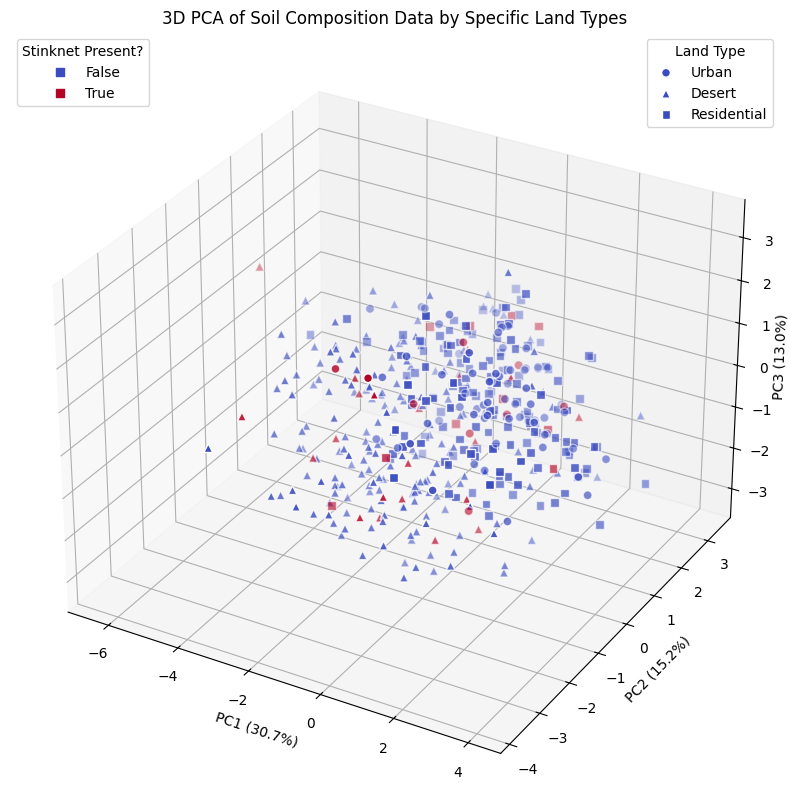

In [15]:

#plot data, Color = True/False stinknet, Shape = land type
markers = {'Urban': 'o' , 'Desert':'^' , 'Residential':'s'}

fig4 = plt.figure(figsize = (10,10))
ax4 = fig4.add_subplot(1,1,1, projection = '3d')

for landType in targetLandTypes:
    subset = filteredPCA[filteredPCA['Land_Type'] == landType]

    scatter = ax4.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        c=subset['Present?'],
        cmap='coolwarm',
        marker = markers[landType],
        label = 'Land Type',
        s=40,
        edgecolors='w'
    )

shape_legend = ax4.legend(['Urban','Desert','Residential'],title='Land Type')
ax4.add_artist(shape_legend)

color_legend = ax4.legend(handles = scatter.legend_elements()[0],
                         labels=['False','True'],
                         title = 'Stinknet Present?',
                         loc = 'upper left')

ax4.set_title('3D PCA of Soil Composition Data by Specific Land Types')
ax4.set_xlabel('PC1 (30.7%)')
ax4.set_ylabel('PC2 (15.2%)')
ax4.set_zlabel('PC3 (13.0%)',labelpad=-2)